In [1]:
import numpy as np

In [2]:
class SimpleLinearRegression:
  def __init__(self):
    self.coefficient_ = None
    self.intercept_ = None
    self.r2score_ = None
  def fit (self, X, y):
    n = len(X)
    X_b = np.c_[np.ones((n,1)), X]

    self.coefficients_ = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
    self.intercept_ = self.coefficients_[0]

    y_pred = X_b.dot(self.coefficients_)

    self.r2score_ = 1 - (np.sum((y - y_pred)**2)) / np.sum((y - np.mean(y))**2)

  def predict(self , X):
    X_b = np.c_[np.ones((len(X),1)) , X]
    return X_b.dot(self.coefficients_)

In [3]:
X_simple = np.array([1,2,3,4,5,6,7,9,10]).reshape(-1,1)
y_simple = np.array([2,4,5,4,7,9,8,10,12])

slr = SimpleLinearRegression()
slr.fit(X_simple, y_simple)

print(f'Simple LR Xoenfficients:{slr.coefficients_}')
print(f'R2 Score: {slr.r2score_}')

Simple LR Xoenfficients:[1.425 1.025]
R2 Score: 0.9278246753246754


In [4]:
import matplotlib.pyplot as plt

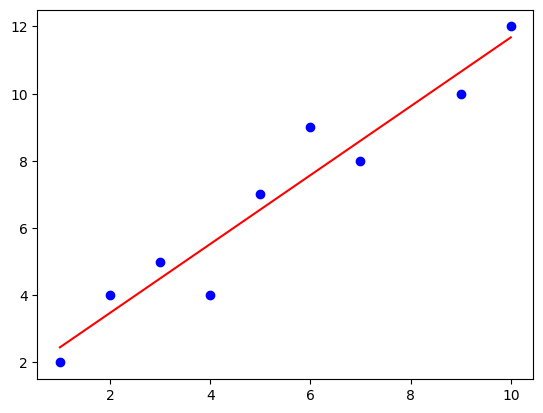

In [5]:
plt.scatter(X_simple, y_simple , color = 'blue' , label ='Data')
plt.plot(X_simple, slr.predict(X_simple), color='red')
plt.show()

In [6]:
class MultipleLinearRegression:
  def __init__(self) :
    self.coefficients_ = None
    self.intercept_ = None
    self.r2score_ = None

  def fit(self ,X, y):
    n = X.shape[0]
    X_b = np.c_[np.ones((n,1)) ,X]
    self.coefficients_ = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
    self.intercept_ = self.coefficients_[0]

    y_pred = X_b.dot(self.coefficients_)

    self.r2score_ = 1 - (np.sum(y - y_pred) ** 2) / np.sum(y - np.mean(y))
    self.y_pred = y_pred

  def predict(self, X):
    X_b = np.c_[np.ones((X.shape[0] , 1)) , X]
    return X_b.dot(self.coefficients_)


In [7]:
np.random.seed(42)

X1 = np.random.randint(1 ,11, 15)
X2 = np.random.randint(1 ,11, 15)

X_multi = np.column_stack((X1 , X2))
y_multi = 1 + 2 * X1 + 3* X2 + np.random.randn(15) * 2

In [8]:
y_multi

array([28.91123455, 15.22184518, 38.69801285, 29.75139604, 19.79872262,
       35.4166125 ,  8.79658678, 48.70455637, 34.97300555, 35.88457814,
       13.64508982, 44.5583127 , 26.41772719, 24.08065975, 22.3436279 ])

In [9]:
X_multi

array([[ 7,  5],
       [ 4,  2],
       [ 8,  8],
       [ 5,  6],
       [ 7,  2],
       [10,  5],
       [ 3,  1],
       [ 7, 10],
       [ 8,  6],
       [ 5,  9],
       [ 4,  1],
       [ 8, 10],
       [ 8,  3],
       [ 3,  7],
       [ 6,  4]])

In [10]:
mlr = MultipleLinearRegression()
mlr.fit(X_multi , y_multi)

print(f'Multi LR Xoenfficients:{mlr.coefficients_}')
print(f'R2 Score: {mlr.r2score_}')

Multi LR Xoenfficients:[-0.025293    2.14085712  2.89217279]
R2 Score: 1.0000000000020788


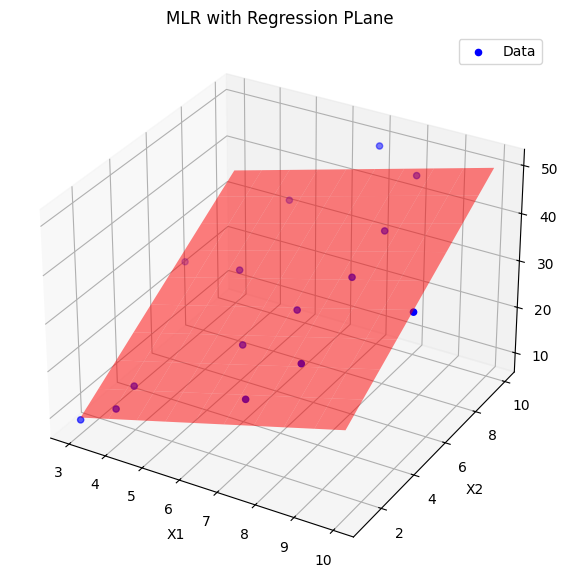

In [11]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection = '3d')

ax.scatter(X_multi[: , 0], X_multi[:,1], y_multi, color = 'blue', label = 'Data')

X1_surf , X2_surf = np.meshgrid(
    np.linspace(X_multi[:,0].min() ,X_multi[:,0].max() , 10) ,
    np.linspace(X_multi[:,1].min() ,X_multi[:,1].max() , 10)
)

pred_surf = mlr.predict(np.c_[X1_surf.ravel(), X2_surf.ravel()]).reshape(X1_surf.shape)

ax.plot_surface(X1_surf, X2_surf, pred_surf, color = 'red',alpha= 0.5 , rstride = 1, cstride = 1)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('y')
ax.set_title("MLR with Regression PLane")
ax.legend()
plt.show()